In [41]:

import pandas as pd 
pd.options.mode.chained_assignment = None  # default='warn'
import glob 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns 
import numpy as np 
import os
import scipy.stats
from scipy.spatial.distance import jensenshannon
import sys

from config import home_path, llm_review_path

sys.path.insert(1, home_path) 
from common_functions import (
    my_colors, 
    format_p, 
    get_pfam_info, 
    mean_confidence_interval, 
    sort_dict_by_key, 
    sort_dict_by_value,
    three_letter_to_one_letter,
)
import pickle 
import json

figure_path = llm_review_path + "high_res_figures/length_figure/clinvar_misclassification/"
def save_figure(fig, name, root_path = figure_path, save_svg = True):
    fig.savefig(root_path + name + ".png", bbox_inches = "tight")
    if save_svg:
        fig.savefig(root_path + name + ".svg", format="svg", dpi = 1200, bbox_inches = "tight")
 



In [42]:

def entropy(lst):
    e = list(map(lambda x : x * np.log2(x), lst))
    e = -1 * np.sum(e)
    return e


regular_aas = ['P','S','L','A','V','G','T','E','R','Q','D','F','I','H','Y','N','K','C','W','M']


def augment_masked_df_with_site_entropy(df, limit_normal_aas = True, return_entropy = True):
    df["name"] = df["ref_aa"] + df["aa_pos"].astype(str) + df["token_str"]
    df = df.loc[df["token_str"].isin(regular_aas)]
    variant_to_s1 = {}
    variant_to_adj_prob = {}
    variant_to_site_entropy = {}
    for pos, sub_df in df.groupby("aa_pos"):
        v_to_adj_score = {}
        valid_prob_total = np.sum(sub_df["score"])
        for index, row in sub_df.iterrows():
            v_to_adj_score[row["name"]] = row["score"] / valid_prob_total
        
        sub_df["adj_score"] = sub_df["name"].apply(lambda x : v_to_adj_score[x])
        
        wt_val = sub_df.loc[sub_df["ref_aa"] == sub_df["token_str"]]
        assert len(wt_val) == 1
        wt_score = wt_val.iloc[0]["adj_score"]
        
        adj_prob_list = []
        for index, row in sub_df.iterrows():
            variant_to_s1[row["name"]] = np.log(row["adj_score"]) - np.log(wt_score)
            variant_to_adj_prob[row["name"]] = row["adj_score"] / valid_prob_total
            adj_prob_list.append(row["adj_score"] / valid_prob_total)
        ent_val = entropy(adj_prob_list)
        
        for name in sub_df["name"].values: variant_to_site_entropy[name] = ent_val

    if return_entropy:
        df["site_entropy"] = df["name"].apply(lambda x : variant_to_site_entropy[x])
            
    df["s1"] = df["name"].apply(lambda x : variant_to_s1[x])
    df["adj_score"] = df["name"].apply(lambda x : variant_to_adj_prob[x])
    
    df = df.set_index("name")
    return df



In [43]:
model = "esm_1b"

long_seq_path = llm_review_path + "masked_results/tiled_long_sequences/esm_1b/" # can be any model
files = glob.glob(long_seq_path + "*.csv.gz")

gene_to_files = {}
for fn in files:
    name = fn.replace(long_seq_path, "").replace(".csv.gz", "")
    name = name.split("_HUMAN_")[0]
    if name in gene_to_files.keys():
        gene_to_files[name].append(fn)
    else:
        gene_to_files[name] = [fn]

In [44]:
model_info = pd.read_csv("./final_notebooks/model_info.txt", delimiter = "\t")
model_to_display_name = {
    "esm_1_43M" : "ESM-1 (43M) UR50",
    "esm_1_85M" : "ESM-1 (85M) UR50",
    "esm_1_UR50" : "ESM-1 (670M) UR50S",
    "esm_1_UR50D" : "ESM-1 (670M) UR50D",
    "esm_1_UR100" : "ESM-1 (670M) UR100",
    "esm_1b" : "ESM-1b (650M) UR50",
    "esm_1v" : "ESM-1v (650M) UR90",
    "esm_2_8M" : "ESM-2 (8M) UR50",
    "esm_2_35M" : "ESM-2 (35M) UR50",
    "esm_2_150M" : "ESM-2 (150M) UR50",
    "esm_2_650M" : "ESM-2 (650M) UR50",
    "esm_2" : "ESM-2 (3B) UR50",
    "esm_2_15B" : "ESM-2 (15B) UR50",
    "protbert" : "ProtBERT (420M) UR100"
}

model_order = [
    "esm_1_43M",
    "esm_1_85M",
    "esm_1_UR50",
    "esm_1_UR50D",
    "esm_1_UR100", 
    "esm_1b", 
    "esm_1v",
    "protbert",
    "esm_2_8M", 
    "esm_2_35M",
    "esm_2_150M", 
    "esm_2_650M", 
    "esm_2", 
    "esm_2_15B" 
]

In [45]:

name_to_counter = {}

names = ["uniref50", "uniref90", "uniref100"]
for name in names:
    

    with open(f"{home_path}singh/nlp_review/uniprot_lengths/{name}_lengths.pkl", "rb") as f:
        data = pickle.load(f)
    f.close()

    counter = {
        "1-511" : 0,
        "512-1022" : 0,
        "1023-2046" : 0,
        "2047+" : 0
    }

    for k in data:
        if k < 512:
            counter["1-511"] += 1
        elif k < 1023:
            counter["512-1022"]+=1
        elif k < 2047:
             counter["1023-2046"]+=1
        else:
            counter["2047+"] += 1
            
    
    name_to_counter[name] =counter


counter = {
    "1-511" : 0,
    "512-1022" : 0,
    "1023-2046" : 0,
    "2047+" : 0
}

human_df = pd.read_csv(llm_review_path + "data/uniprotkb_taxonomy_id_9606_AND_reviewed_2023_10_18.tsv", delimiter = "\t")
for index, row in human_df.iterrows():
    seq = row["Sequence"]
    k = len(seq)
    if k < 512:
        counter["1-511"] += 1
    elif k < 1023:
        counter["512-1022"]+=1
    elif k < 2047:
        counter["1023-2046"]+=1
    else:
        counter["2047+"] += 1
        
        
# name_to_counter["Human Proteins"] = counter

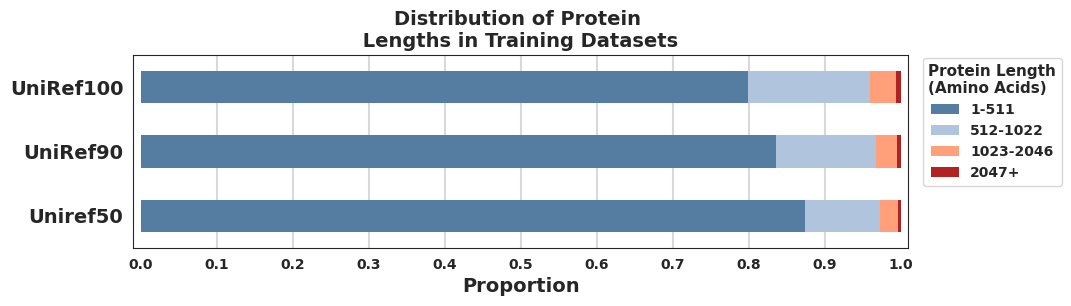

In [46]:

colors=['#557ca1', 'lightsteelblue', 'lightsalmon', 'firebrick']

sns.set_style("white")
fig, ax = plt.subplots(figsize = (10,2.5))

df1 = pd.DataFrame.from_dict(name_to_counter).transpose()
df1 = df1.div(df1.sum(axis=1), axis=0).reset_index()
df1.plot( 
    kind = 'barh',  
    stacked = True,  
    title = 'Distribution of Protein \n Lengths in Training Datasets ',  
    mark_right = True,
    color = colors,
    zorder = 100,
    linewidth=0,
    ax = ax
)


for i in np.arange(0.1, 0.91, 0.1):
    ax.axvline(i, color = "black", alpha = 0.15, zorder = 0)

ax.set_title(ax.get_title(), fontweight='bold',fontsize = 14 )
legend = ax.legend(bbox_to_anchor=(1.01, 1.02), title = "Protein Length\n(Amino Acids)", fontsize = 12, prop={'weight': 'bold'})
legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(11)

ax.set_xlim(left = -0.01, right = 1.01)

ax.set_yticklabels(["Uniref50", "UniRef90", "UniRef100"], fontsize = 14, fontweight='bold')
ax.set_xticks(list(np.arange(0,1.01,0.1)))
ax.set_xticklabels(ax.get_xticklabels(), fontweight = "bold")
ax.set_xlabel("Proportion", fontsize = 14, fontweight='bold')


save_figure(fig, "dataset_protein_lengths")


In [47]:
df1["over_1022"] = df1["1023-2046"] + df1["2047+"]
df1.to_csv(llm_review_path + "figure_panels/submission/source_data/fig_5a.csv")

# llm_review_path

In [48]:

def extract_coding_info_from_name(name_str, return_ref = True, return_pos = False, return_alt = False):
    try:
        pieces = name_str.split("(p.")
        needed_piece = pieces[1]
        ref_aa = needed_piece[:3]
        piece_2 = needed_piece.split(")")[0]
        if piece_2[-1] == "=":
            alt_aa = ref_aa
            aa_pos = int(piece_2[3:-1])
        else:
            alt_aa = piece_2[-3:]
            aa_pos = int(piece_2[3:-3])
        if return_alt:
            return alt_aa
        elif return_pos:
            return aa_pos
        else:
            return ref_aa
    except:
        print("error", name_str)
        return None
 

def get_clinvar_df(clinvar_fn):
    p_lp_annotations = [ 'Pathogenic/Likely pathogenic','Likely pathogenic',  'Pathogenic']
    b_lb_annotations = ['Likely benign','Benign', 'Benign/Likely benign']
    vus_annotations = ["Uncertain significance/Uncertain risk allele", "Uncertain significance"]

    human_info = pd.read_csv(llm_review_path + "data/uniprotkb_taxonomy_id_9606_AND_reviewed_2023_10_18.tsv", delimiter = "\t")
    entry_to_uniport_id = dict(zip(human_info["Entry Name"].values,human_info["Entry"].values))
    gene_to_entry = {}
    for index, row in human_info.iterrows():
        gene_vals = row["Gene Names"]
        if pd.isna(gene_vals):
            gene_vals = [entry_name.replace("_HUMAN", "")]
        else:
            
            gene_vals = row["Gene Names"].split(" ")
            entry_name = row["Entry Name"]
        for g in gene_vals:
            gene_to_entry[g.upper()] = entry_name

    df = pd.read_csv(clinvar_fn, delimiter = "\t")
    df = df.loc[df["Type"] == "single nucleotide variant"] # removes indels + other non SNP variants 

    my_regex = ".*c\.[0-9]*[ATCG]>[ATCG] \(p\.[A-Z][a-z]{2}[0-9]*[^_]*\)"
    df2 = df.loc[df["Name"].str.match(my_regex)] # gets the matches to the regex 
    df2["ref_aa"] = df2["Name"].apply(lambda x : extract_coding_info_from_name(x, return_ref = True,  return_pos = False, return_alt = False))
    df2["alt_aa"] = df2["Name"].apply(lambda x : extract_coding_info_from_name(x, return_ref = False, return_pos = False, return_alt = True))
    df2["aa_pos"] = df2["Name"].apply(lambda x : extract_coding_info_from_name(x, return_ref = False, return_pos = True,  return_alt = False))
    clinvar_missense = df2.loc[
        (df2["alt_aa"] != df2["ref_aa"]) &
        (df2["alt_aa"] != "Ter") &
        (df2["ref_aa"] != "Ter") &
        (df2["aa_pos"] != 1)
    ]

    clinvar_missense["ref_aa_1_letter"] = clinvar_missense["ref_aa"].apply(lambda x : three_letter_to_one_letter[x.upper()])
    clinvar_missense["alt_aa_1_letter"] = clinvar_missense["alt_aa"].apply(lambda x : three_letter_to_one_letter[x.upper()])
    clinvar_missense["variant_name"] = clinvar_missense["ref_aa_1_letter"] +clinvar_missense["aa_pos"].astype(str) + clinvar_missense["alt_aa_1_letter"]

    clinvar_missense_annotated = clinvar_missense.loc[
        clinvar_missense["ClinicalSignificance"].isin(p_lp_annotations + b_lb_annotations + vus_annotations)
    ]

    clinvar_missense_annotated["PLP"] = clinvar_missense["ClinicalSignificance"].apply(lambda x : x in p_lp_annotations)
    clinvar_missense_annotated["BLB"] = clinvar_missense["ClinicalSignificance"].apply(lambda x : x in b_lb_annotations)
    clinvar_missense_annotated["VUS"] = clinvar_missense["ClinicalSignificance"].apply(lambda x : x in vus_annotations)

    clinvar_genes = set(clinvar_missense_annotated["GeneSymbol"])

    not_found_genes = set()
    found_genes = set()

    gene_symbol_map = {}

    for g in clinvar_genes:
        gene_found = False 
        g = g.upper()
        if g in gene_to_entry.keys():
            gene_found = True  
            gene_symbol_map[g] = gene_to_entry[g]
        else:
            if ";" in g:
                pieces = g.split(";")
                for piece in pieces:
                    if piece in gene_to_entry.keys():
                        gene_found = True
                        gene_symbol_map[g] = gene_to_entry[piece]

            if "-" in g:
                pieces = g.split("-")
                for piece in pieces:
                    if piece in gene_to_entry.keys():
                        gene_found = True 
                        gene_symbol_map[g] = gene_to_entry[piece]

        if gene_found:
            found_genes.add(g)
        else:
            not_found_genes.add(g)

    clinvar_missense_annotated["mapped_gene_file"] = clinvar_missense_annotated["GeneSymbol"].apply(lambda x : gene_to_entry[x] if x in gene_to_entry.keys() else None)
    clinvar_missense_annotated["uniprot"] = clinvar_missense_annotated["mapped_gene_file"].apply(lambda x : entry_to_uniport_id[x] if x in entry_to_uniport_id.keys() else None)
    
    return clinvar_missense_annotated

In [49]:
name_to_counter = {}

counter = {
    "1-511" : 0,
    "512-1022" : 0,
    "1023-2046" : 0,
    "2047+" : 0
}

human_df = pd.read_csv(llm_review_path + "data/uniprotkb_taxonomy_id_9606_AND_reviewed_2023_10_18.tsv", delimiter = "\t")
for index, row in human_df.iterrows():
    seq = row["Sequence"]
    k = len(seq)
    if k < 512:
        counter["1-511"] += 1
    elif k < 1023:
        counter["512-1022"]+=1
    elif k < 2047:
        counter["1023-2046"]+=1
    else:
        counter["2047+"] += 1
        
        
name_to_counter["a_Human_Proteins"] = counter

vogelstein = pd.read_csv(llm_review_path + "data/Vogelstein2013_125drivers_sequences.csv", index_col = 0)

counter = {
    "1-511" : 0,
    "512-1022" : 0,
    "1023-2046" : 0,
    "2047+" : 0
}
for index, row in vogelstein.iterrows():
    seq = row["sequence"]
    k = len(seq)
    if k < 512:
        counter["1-511"] += 1
    elif k < 1023:
        counter["512-1022"]+=1
    elif k < 2047:
        counter["1023-2046"]+=1
    else:
        counter["2047+"] += 1

name_to_counter["d_Vogelstein"] = counter
        
acmg_73 = pd.read_csv(llm_review_path + "data/ACMG_73_sequences.csv")


counter = {
    "1-511" : 0,
    "512-1022" : 0,
    "1023-2046" : 0,
    "2047+" : 0
}
for index, row in acmg_73.iterrows():
    seq = row["Sequence"]
    k = len(seq)
    if k < 512:
        counter["1-511"] += 1
    elif k < 1023:
        counter["512-1022"]+=1
    elif k < 2047:
        counter["1023-2046"]+=1
    else:
        counter["2047+"] += 1

name_to_counter["c_acmg"] = counter


name_to_length = dict(zip(human_df["Entry Name"].values, human_df["Length"].values))

clinvar_df = get_clinvar_df(home_path + "clinvar/clinvar_versions/variant_summary_09_03_2024.txt")
clinvar_df = clinvar_df.loc[~clinvar_df["mapped_gene_file"].isna()]

examining_genes = set()

for gene, sub_df in clinvar_df.groupby("mapped_gene_file"):
    plp_entries = sub_df.loc[sub_df["PLP"]]
    unique_variants = plp_entries.drop_duplicates("variant_name")
    if len(unique_variants) >= 5:
        examining_genes.add(gene)



human_subset_clinvar = human_df.loc[human_df["Entry Name"].isin(examining_genes)]


counter = {
    "1-511" : 0,
    "512-1022" : 0,
    "1023-2046" : 0,
    "2047+" : 0
}


for index, row in human_subset_clinvar.iterrows():
    seq = row["Sequence"]
    k = len(seq)
    if k < 512:
        counter["1-511"] += 1
    elif k < 1023:
        counter["512-1022"]+=1
    elif k < 2047:
        counter["1023-2046"]+=1
    else:
        counter["2047+"] += 1
        
name_to_counter["b_clinvar"] = counter


/tmp/ipykernel_5977/3240202739.py:43: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(clinvar_fn, delimiter = "\t")


              index     1-511  512-1022  1023-2046     2047+
1      d_Vogelstein  0.319328  0.285714   0.260504  0.134454
2            c_acmg  0.356164  0.315068   0.205479  0.123288
3         b_clinvar  0.407830  0.342034   0.176183  0.073953
0  a_Human_Proteins  0.618838  0.268664   0.091399  0.021100


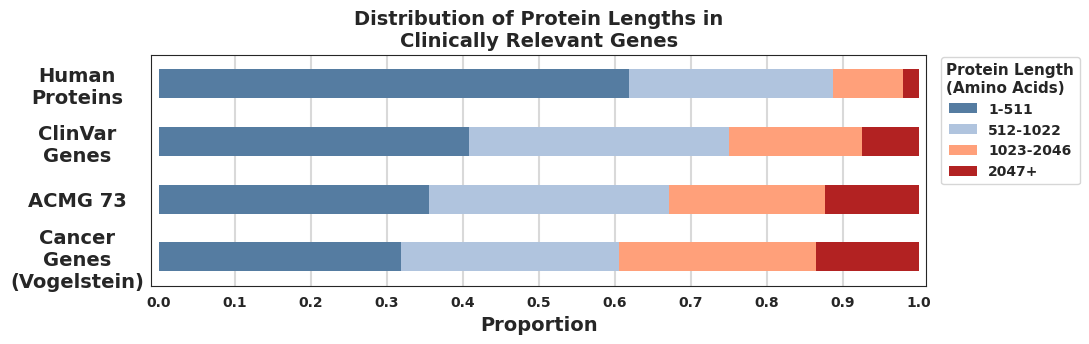

In [50]:
colors=['#557ca1', 'lightsteelblue', 'lightsalmon', 'firebrick']

sns.set_style("white")
fig, ax = plt.subplots(figsize = (10,3))

df1 = pd.DataFrame.from_dict(name_to_counter).transpose()
df1 = df1.div(df1.sum(axis=1), axis=0).reset_index()
df1 = df1.sort_values(by = "index", ascending = False)


df1.plot( 
    kind = 'barh',  
    stacked = True,  
    title = 'Distribution of Protein Lengths in\nClinically Relevant Genes',  
    mark_right = True,
    color = colors,
    zorder = 100,
    linewidth=0,
    ax = ax
)

for i in np.arange(0.1, 0.91, 0.1):
    ax.axvline(i, color = "black", alpha = 0.15, zorder = 0)

ax.set_title(ax.get_title(), fontweight='bold',fontsize = 14 )
legend = ax.legend(bbox_to_anchor=(1.01, 1.02), title = "Protein Length\n(Amino Acids)", fontsize = 12, prop={'weight': 'bold'})
legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(11)

ax.set_yticklabels(["Cancer\nGenes\n(Vogelstein)", "ACMG 73", "ClinVar\nGenes", "Human\nProteins"], fontsize = 14, fontweight = "bold", horizontalalignment = "center")
ax.tick_params(axis='y', which='major', pad=50)

ax.set_xticks(list(np.arange(0,1.01,0.1)))
ax.set_xlim(right = 1.01, left=-0.01)
ax.set_xticklabels(ax.get_xticklabels(), fontweight = "bold")
ax.set_xlabel("Proportion", fontsize = 14, fontweight='bold')


print(df1)

In [51]:
df1["over_1022"] = df1["1023-2046"] + df1["2047+"]

df1.to_csv(llm_review_path + "figure_panels/submission/source_data/fig_5b.csv")

In [52]:
df_pieces = []
labels = []
data = []

for m in model_order:
    fn = f"{home_path}clinvar/nlp_review_misclassification/f_results_all/summary_stats_{m}.csv"
    dfo = pd.read_csv(fn)
    dfo["model"] = model_to_display_name[m]
    data.append(dfo["proportion_different"].values)
    df_pieces.append(dfo)
    labels.append(model_to_display_name[m].replace(" ", "\n"))
    
df_y = pd.concat(df_pieces)
df_y = df_y[["model", "proportion_different", "gene"]]

supp_table_path = llm_review_path + "figure_panels/submission/table_csvs/"
df_y.to_csv(supp_table_path + 'gene_ref_aas_different.csv', index = False)

In [53]:
df_y

,model,proportion_different,gene
0,ESM-1 (43M) UR50,0.197309,UBP47_HUMAN
1,ESM-1 (43M) UR50,0.196570,MDR3_HUMAN
2,ESM-1 (43M) UR50,0.113413,TEX2_HUMAN
3,ESM-1 (43M) UR50,0.181521,BLTP1_HUMAN
4,ESM-1 (43M) UR50,0.126731,RNBP6_HUMAN
...,...,...,...
2293,ESM-2 (15B) UR50,0.084156,MUC12_HUMAN
2294,ESM-2 (15B) UR50,0.179061,EVPL_HUMAN
2295,ESM-2 (15B) UR50,0.138075,TNKS1_HUMAN
2296,ESM-2 (15B) UR50,0.135780,RHG35_HUMAN


Text(0.5, 1.01, 'Per-gene rates of prediction mismatch between tiles')

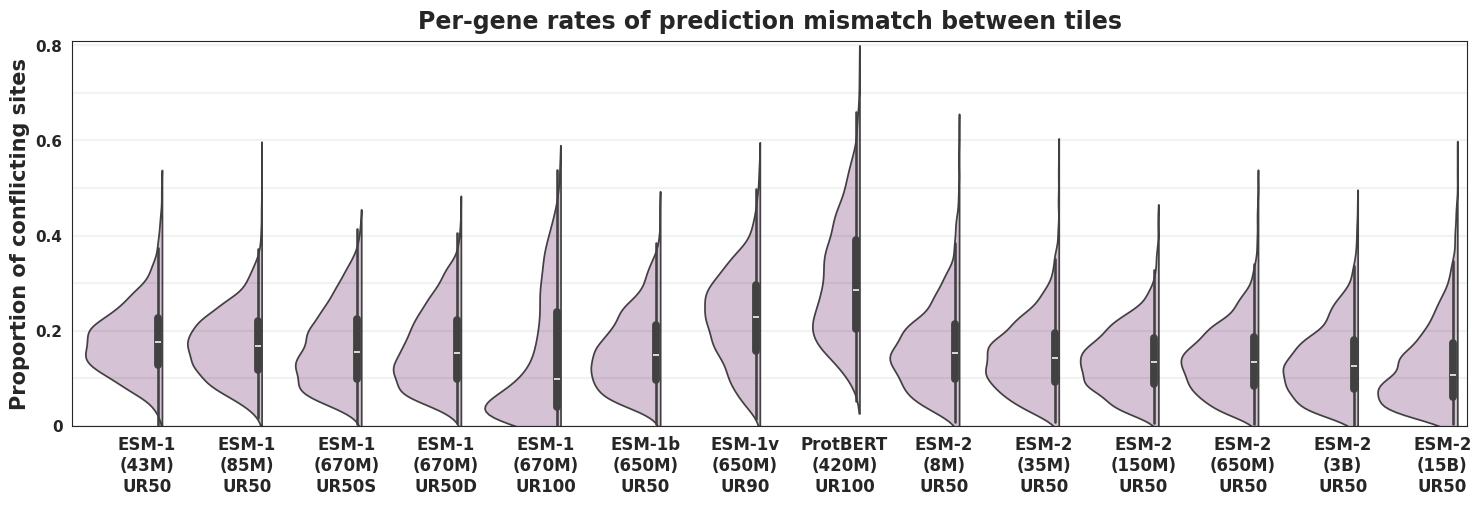

In [54]:
fig, ax = plt.subplots(figsize = (18,5))

sns.violinplot(data, split = True, color = "thistle", cut = True,)
ax.set_ylim(top = 0.81, bottom = 0)
for y_val in ax.get_yticks():
    ax.axhline(y=y_val, zorder = 1, color = "black", alpha = 0.05)
    
x_ticks = np.arange(0.25, 14.25, 1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(labels, fontweight = "bold", fontsize = 12)
ax.set_yticks([0,0.2,0.4,0.6,0.8])
ax.set_yticklabels([0,0.2,0.4,0.6,0.8], fontsize = 11, fontweight = "bold")

ax.set_ylabel("Proportion of conflicting sites", fontsize =15, fontweight = "bold")

ax.set_title("Per-gene rates of prediction mismatch between tiles", fontweight = "bold", fontsize =17, y = 1.01 )



In [55]:
save_figure(fig, "violin_plot_discordant_ref")

In [36]:

min_dist_alphafold_path = llm_review_path + "src/alphafold_long_seqs_min_distance_summaries.pkl"

with open(min_dist_alphafold_path, "rb") as f:
    data = pickle.load(f)
f.close()

s1=set()
uniprot_to_counter = {}

for k in data.keys():
    uniprot = k.split("-")[1]
    s1.add(uniprot)
    if uniprot in uniprot_to_counter.keys():
        uniprot_to_counter[uniprot] += 1
    else:
        uniprot_to_counter[uniprot] = 1
  


structure_lengths = []
min_distance_angstroms = []
min_distances_percentiles = []

af_table = []

for k, v in data.items():
    uniprot = k.split("-")[1]
    if uniprot_to_counter[uniprot] == 1:
        structure_lengths.append(v["structure_length"])
        min_distance_angstroms.append(v["min_distance_over_1022_away"])
        min_distances_percentiles.append(v["min_distnace_percentile"])
        af_table.append([ k[:-1]  , v["min_distance_over_1022_away"]])
        
valid_prots = len(structure_lengths)

res_d = {}

total_vals = len(min_distance_angstroms)

print(total_vals)
for cutoff in np.arange(1,100,1):
    v1 = list(filter(lambda x : x <= cutoff, min_distance_angstroms))
    res_d[int(cutoff)] = len(v1) / total_vals
    
    
x_plot = [0,1,2,3]
x = [5, 8, 16, 24, 32]
x_label = ["$" + str(c) + "\ \mathrm{\AA}$" for c in x]
y = [res_d[i] for i in x] 
y2 = [1 - res_d[i] for i in x] 


df1 = pd.DataFrame([x_label,y,y2]).transpose().rename(columns = {0 : "index", 1: "Has LRC", 2: "No LRC"})
df1 = df1.iloc[::-1]

x_label = x_label[::-1]





ax.legend(bbox_to_anchor=(1.01, 1.02), fontsize = 10)
ax.set_xlim(left = -0.01, right = 1.01)
ax.set_xticks([0, 0.25,0.5,0.75,1.0])
ax.set_xlabel("Proportion", fontsize = 12)
ax.set_title(ax.get_title(), fontsize = 12)

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, zorder = 1, color = "black", alpha = 0.1)

ax.set_yticklabels(x_label, fontsize = 12)

df1

2091


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


,index,Has LRC,No LRC
4,$32\ \mathrm{\AA}$,0.795791,0.204209
3,$24\ \mathrm{\AA}$,0.72549,0.27451
2,$16\ \mathrm{\AA}$,0.61693,0.38307
1,$8\ \mathrm{\AA}$,0.329986,0.670014
0,$5\ \mathrm{\AA}$,0.162123,0.837877


In [37]:
def list_has_breaks(lst):
    lst = list(map(lambda x : int(x), lst))
    lst_2 = list(range(np.min(lst), np.max(lst) + 1))
    return len(lst) != len(lst_2)


fn_to_long_range_min = []


res_path = home_path + "pisces_dunbrak_lab/distances/" 
res_files = glob.glob(res_path  + "*.json")

for c, fn in enumerate(res_files):
    if c % 50 == 0:
        print("counter ", c)
    with open(fn, "r") as f:
        data = json.load(f)
    f.close()
    
    has_breaks = list_has_breaks(data.keys())
    lst = list(map(lambda x : int(x), data.keys()))
    total_range = np.max(lst) - np.min(lst)
    long_range_min = None
    num_long_range_contacts = 0
    num_long_range_contacts_8a = 0
    for k, v in data.items():
        pos_1 = int(k)
        for k2, v2 in v.items():
            pos_2 = int(k2)
            if abs(pos_1 - pos_2) >= 1022:
                if v2 <= 5:
                    num_long_range_contacts += 1
                    
                if v2 <= 8:
                    num_long_range_contacts_8a += 1
                
                if long_range_min is None:
                    long_range_min = v2
                elif v2 < long_range_min:
                    long_range_min = v2
                    
                    
    fn_to_long_range_min.append({ 
        "name" : fn.replace(res_path, "").replace(".json", ""), 
        "long_range_min": long_range_min,
        "length" : total_range,
        "covered_positions" : len(lst),
        "missing_positions" : total_range - len(lst), 
        "has_breaks" : has_breaks,
        "num_lrc" :  num_long_range_contacts,
        "num_lrc_8a" : num_long_range_contacts_8a
    })
    
    
    
    

counter  0
counter  50
counter  100
counter  150
counter  200
counter  250
counter  300
counter  350
counter  400
counter  450
counter  500
counter  550
counter  600
counter  650
counter  700
counter  750
counter  800
counter  850
counter  900
counter  950


In [38]:
pdb_summary_vals = []

for entry in fn_to_long_range_min:
    pdb_summary_vals.append([
        entry["name"],
        entry["long_range_min"],
        "PDB entries (PISCES culled)"
    ])
pdb_table = pd.DataFrame(pdb_summary_vals, columns = ["entry", "long_range_min_distance", "source"])
pdb_table = pdb_table.loc[~pdb_table["long_range_min_distance"].isna()]
len(pdb_table.loc[pdb_table["long_range_min_distance"] <=8 ]) / len(pdb_table), len(pdb_table)

(0.41784037558685444, 639)

/tmp/ipykernel_5977/3738172784.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontsize = 12, fontweight="bold")


Text(0.5, 0, 'Proportion')

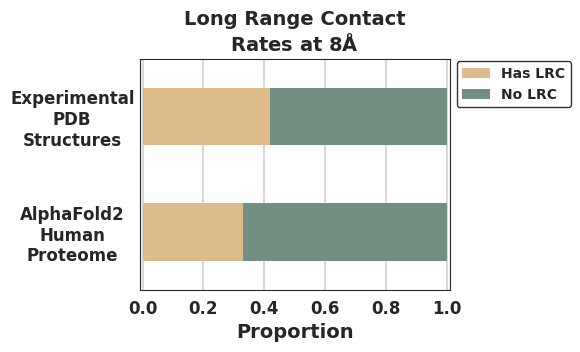

In [39]:
colors = ["#debb8a" , "#728f82"]

data =  {
    "AlphaFold2\nHuman\nProteome" : {"Has LRC" : 0.329986, "No LRC" : 0.670014},
    "Experimental\nPDB\nStructures" :  {"Has LRC" : 0.4178, "No LRC" : 1-0.4178},
}

df1 = pd.DataFrame(data).T
fig, ax = plt.subplots(figsize=(4,3))
df1.plot( 
    kind = 'barh',  
    stacked = True,  
    title = 'Long Range Contact\nRates at 8$\mathbf{\AA}$',  
    mark_right = True,
    color = colors,
    zorder = 10,
    linewidth= 0,
    ax = ax
)


ax.set_title(ax.get_title(), fontweight='bold',fontsize = 14 )
legend = ax.legend(bbox_to_anchor=(1.0, 0.9 ,-0.1,0.12), fontsize = 12, prop={'weight': 'bold'}, edgecolor = "black")

ax.set_yticklabels(ax.get_yticklabels(), fontsize = 12, fontweight="bold", horizontalalignment = "center")
ax.tick_params(axis='y', which='major', pad=45)
ax.set_xlim(right = 1.01, left = -0.01)
ax.set_xticklabels(ax.get_xticklabels(), fontsize = 12, fontweight="bold")


for x_val in ax.get_xticks():
    ax.axvline(x = x_val, zorder = 1, color = "black", alpha = 0.15)
    

    
ax.set_xlabel("Proportion", fontsize = 14, fontweight="bold")

In [40]:
af_table = pd.DataFrame(af_table, columns = ["entry", "long_range_min_distance"])
af_table["source"] = "AlphaFold2"
print(len(af_table.loc[af_table["long_range_min_distance"]<=8]) / len(af_table))

len(af_table), len(pdb_table)

0.3299856527977044


(2091, 639)

In [20]:
joined_long_range = pd.concat([af_table, pdb_table])
joined_long_range.to_csv(supp_table_path + "long_range_entries.csv", index = False)

In [21]:
joined_long_range["source"].value_counts()

source
AlphaFold2                     2091
PDB entries (PISCES culled)     639
Name: count, dtype: int64